## 1. Import dan Load Data

Semua path dibuat relatif terhadap root proyek, karena notebook berada satu tingkat di bawah root pada folder `notebooks/`.

In [3]:
import json
import os
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

raw_files = sorted(RAW_DIR.glob("*.csv"))
assert len(raw_files) == 12, f"Diharapkan 12 CSV stasiun, ditemukan {len(raw_files)}"

station_frames = [pd.read_csv(file_path) for file_path in raw_files]
df_master = pd.concat(station_frames, ignore_index=True)
df_master["datetime"] = pd.to_datetime(
    df_master[["year", "month", "day", "hour"]]
)

coordinates = pd.read_csv(PROCESSED_DIR / "station_coordinates.csv")
rows_before_merge = len(df_master)
df_master = df_master.merge(coordinates, on="station", how="left", validate="many_to_one")
assert len(df_master) == rows_before_merge, "Merge koordinat mengubah jumlah baris"
assert df_master[["lat", "lon"]].notna().all().all(), "Ada stasiun tanpa koordinat"

print(f"Master dataset setelah merge: {df_master.shape[0]:,} baris x {df_master.shape[1]} kolom")
print(f"Rentang waktu: {df_master['datetime'].min()} sampai {df_master['datetime'].max()}")
print("\nDtypes:")
print(df_master.dtypes)
print("\nJumlah baris per stasiun:")
print(df_master["station"].value_counts().sort_index().to_string())

Master dataset setelah merge: 420,768 baris x 21 kolom
Rentang waktu: 2013-03-01 00:00:00 sampai 2017-02-28 23:00:00

Dtypes:
No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                     str
WSPM               float64
station                str
datetime    datetime64[us]
lat                float64
lon                float64
dtype: object

Jumlah baris per stasiun:
station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wansh

## 2. Data Cleaning Dasar

`datetime` dipertahankan sebagai kolom biasa, bukan MultiIndex. Pilihan ini menjaga ekspor Parquet dan operasi pivot/split tetap eksplisit, sementara kombinasi `station` dan `datetime` tetap dipastikan unik.

In [4]:
duplicate_mask = df_master.duplicated(subset=["station", "datetime"], keep="first")
duplicate_count = int(duplicate_mask.sum())
df_master = df_master.loc[~duplicate_mask].copy()

numeric_columns = [
    "No", "year", "month", "day", "hour", "PM2.5", "PM10", "SO2", "NO2",
    "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "lat", "lon"
]
categorical_columns = ["wd", "station"]

for column in numeric_columns:
    df_master[column] = pd.to_numeric(df_master[column], errors="coerce")
for column in categorical_columns:
    df_master[column] = df_master[column].astype("category")

df_master = df_master.sort_values(["station", "datetime"]).reset_index(drop=True)

print(f"Duplikat (station, datetime) yang dihapus: {duplicate_count:,}")
print(f"Duplikat tersisa: {df_master.duplicated(['station', 'datetime']).sum():,}")
print(f"Kolom numerik: {numeric_columns}")
print(f"Kolom kategorikal: {categorical_columns}")

Duplikat (station, datetime) yang dihapus: 0
Duplikat tersisa: 0
Kolom numerik: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'lat', 'lon']
Kolom kategorikal: ['wd', 'station']


## 3. Analisis Missingness Asli

Missingness dihitung dari master dataset setelah deduplikasi, tanpa imputasi atau sampling.

Persentase missing value per kolom:
CO          4.920
O3          3.155
NO2         2.879
SO2         2.144
PM2.5       2.077
PM10        1.533
wd          0.433
DEWP        0.096
TEMP        0.095
PRES        0.093
RAIN        0.093
WSPM        0.076
No          0.000
hour        0.000
day         0.000
month       0.000
year        0.000
station     0.000
datetime    0.000
lat         0.000
lon         0.000

Persentase missing PM2.5 per stasiun:
station
Huairou          2.718
Aotizhongxin     2.638
Shunyi           2.604
Dingling         2.222
Changping        2.207
Dongsi           2.139
Wanshouxigong    1.985
Tiantan          1.931
Gucheng          1.842
Nongzhanguan     1.791
Guanyuan         1.757
Wanliu           1.089


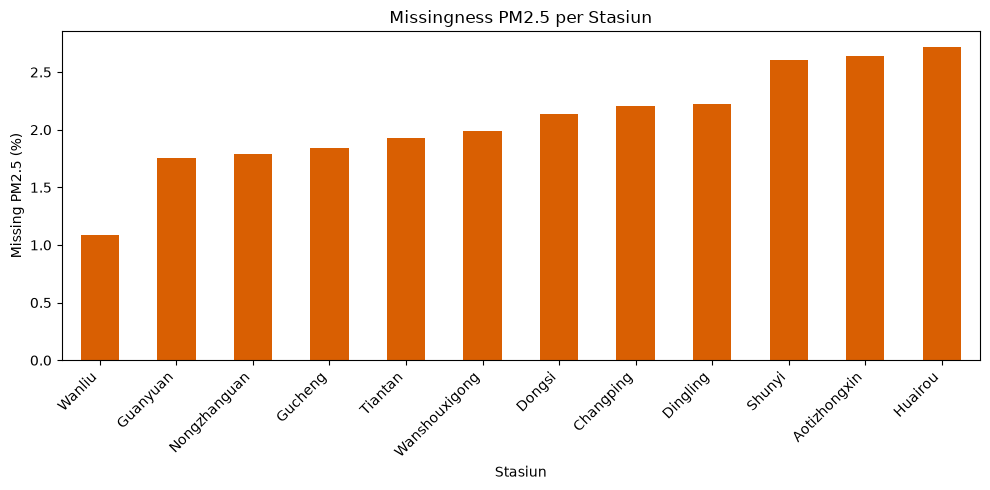

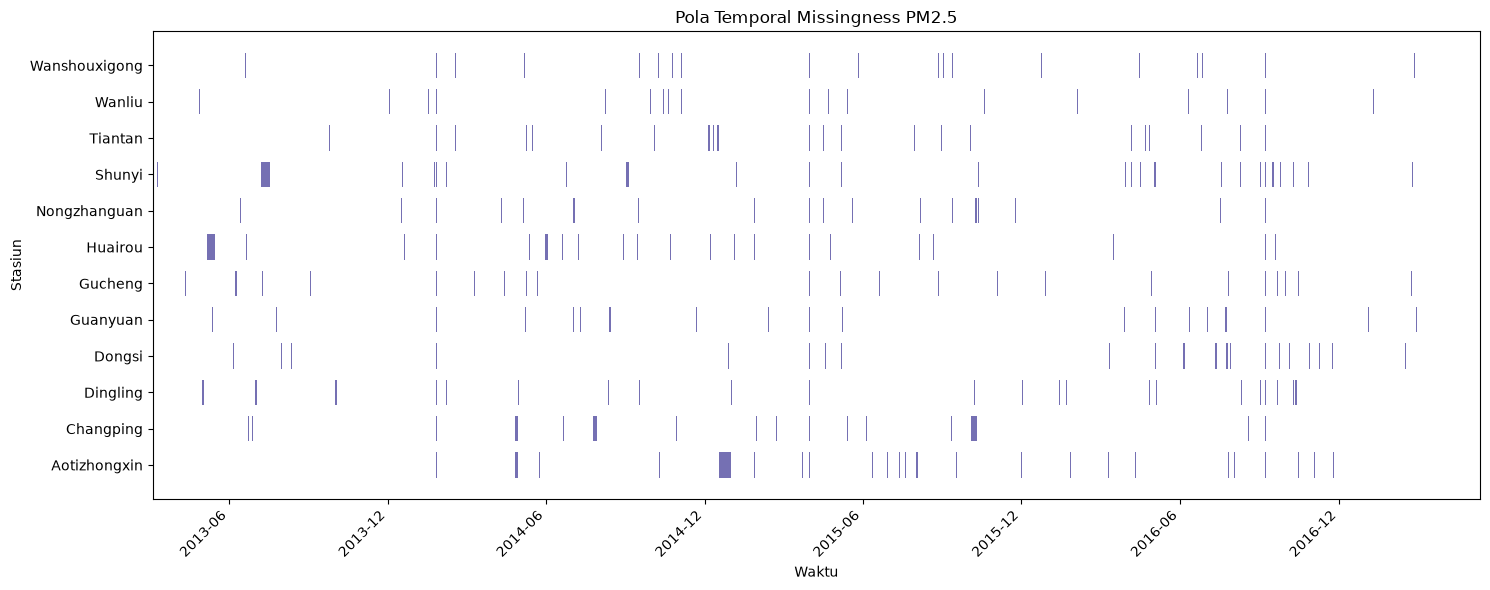

Jumlah interval missing PM2.5: 2,837


In [5]:
missing_percent = (df_master.isna().mean() * 100).sort_values(ascending=False)
print("Persentase missing value per kolom:")
print(missing_percent.round(3).to_string())

pm25_missing_by_station = (
    df_master.groupby("station", observed=True)["PM2.5"]
    .apply(lambda series: series.isna().mean() * 100)
    .sort_values(ascending=False)
)
print("\nPersentase missing PM2.5 per stasiun:")
print(pm25_missing_by_station.round(3).to_string())

plt.figure(figsize=(10, 5))
pm25_missing_by_station.sort_values().plot(kind="bar", color="#d95f02")
plt.title("Missingness PM2.5 per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Missing PM2.5 (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Bentuk interval kontigu untuk gantt chart missingness PM2.5.
missing_intervals = []
for station, station_data in df_master.groupby("station", observed=True):
    station_data = station_data.sort_values("datetime").copy()
    is_missing = station_data["PM2.5"].isna()
    interval_group = is_missing.ne(is_missing.shift()).cumsum()
    for _, interval in station_data[is_missing].groupby(interval_group[is_missing]):
        start = interval["datetime"].min()
        end = interval["datetime"].max() + pd.Timedelta(hours=1)
        missing_intervals.append((station, start, end - start))

fig, axis = plt.subplots(figsize=(15, 6))
stations = sorted(df_master["station"].dropna().unique())
station_positions = {station: position for position, station in enumerate(stations)}
for station, start, duration in missing_intervals:
    axis.barh(station_positions[station], duration.total_seconds() / 86400, left=mdates.date2num(start), height=0.7, color="#7570b3")
axis.set_yticks(range(len(stations)))
axis.set_yticklabels(stations)
axis.xaxis_date()
axis.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axis.set_title("Pola Temporal Missingness PM2.5")
axis.set_xlabel("Waktu")
axis.set_ylabel("Stasiun")
plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(f"Jumlah interval missing PM2.5: {len(missing_intervals):,}")

## 4. Analisis Korelasi Spasial

Korelasi dihitung pairwise pada observasi PM2.5 yang tersedia di kedua stasiun. Jarak antarstasiun dihitung dengan rumus haversine dari koordinat lintang dan bujur.

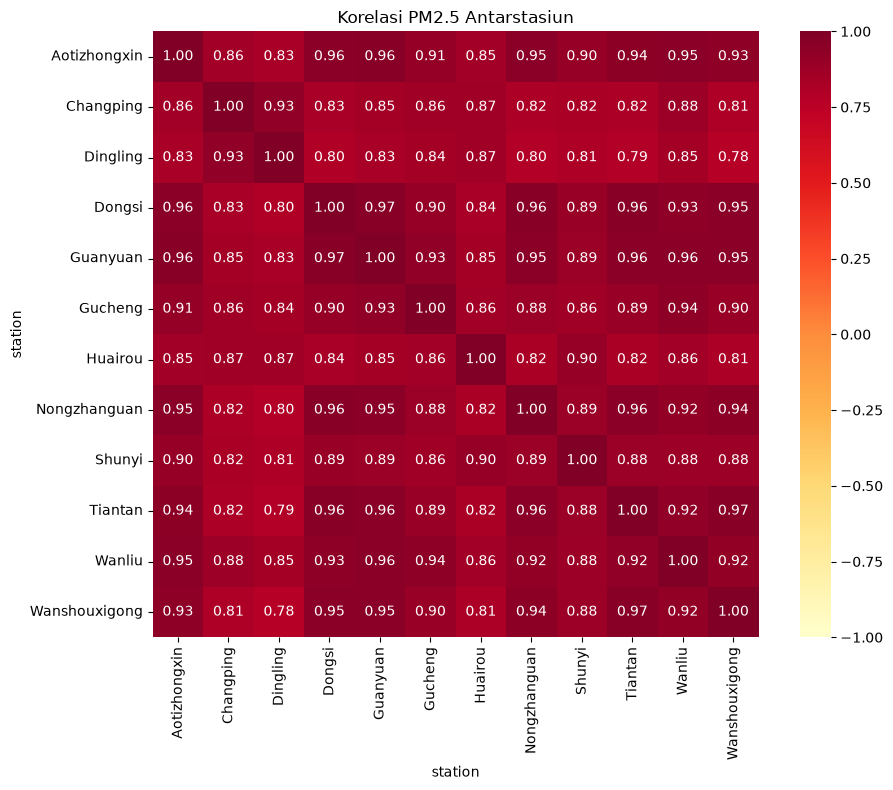

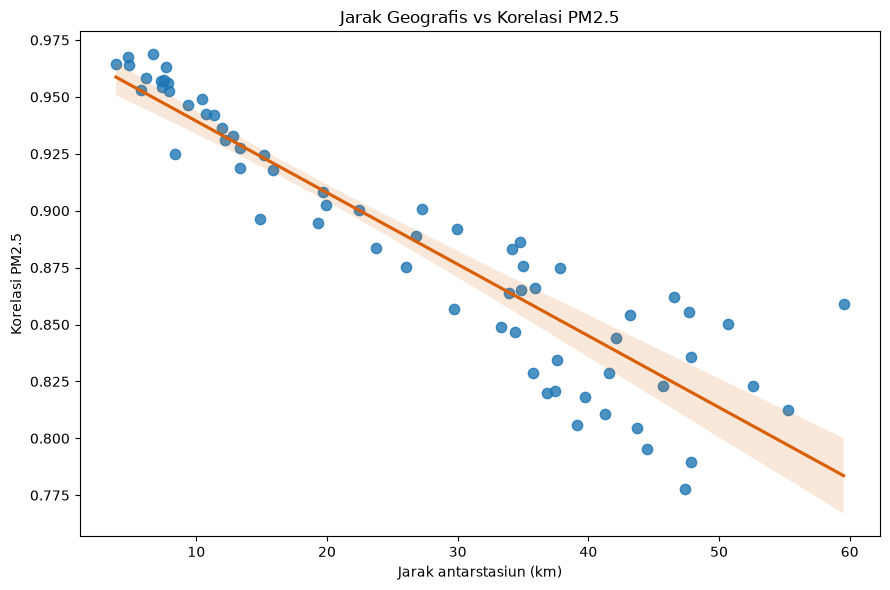

Jumlah pasangan stasiun yang dianalisis: 66


In [6]:
from itertools import combinations

pm25_matrix = df_master.pivot(index="datetime", columns="station", values="PM2.5")
correlation_matrix = pm25_matrix.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="YlOrRd", vmin=-1, vmax=1, square=True)
plt.title("Korelasi PM2.5 Antarstasiun")
plt.tight_layout()
plt.show()

station_locations = (
    df_master[["station", "lat", "lon"]]
    .drop_duplicates("station")
    .set_index("station")
)

def haversine_km(latitude_1, longitude_1, latitude_2, longitude_2):
    earth_radius_km = 6371.0
    latitude_1, longitude_1, latitude_2, longitude_2 = map(
        np.radians, [latitude_1, longitude_1, latitude_2, longitude_2]
    )
    delta_latitude = latitude_2 - latitude_1
    delta_longitude = longitude_2 - longitude_1
    haversine_value = (
        np.sin(delta_latitude / 2) ** 2
        + np.cos(latitude_1) * np.cos(latitude_2) * np.sin(delta_longitude / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(haversine_value))

station_pairs = []
for station_a, station_b in combinations(correlation_matrix.columns, 2):
    correlation = correlation_matrix.loc[station_a, station_b]
    if pd.isna(correlation):
        continue
    location_a = station_locations.loc[station_a]
    location_b = station_locations.loc[station_b]
    station_pairs.append({
        "station_a": station_a,
        "station_b": station_b,
        "distance_km": haversine_km(location_a["lat"], location_a["lon"], location_b["lat"], location_b["lon"]),
        "correlation": correlation,
    })

correlation_distance = pd.DataFrame(station_pairs)
plt.figure(figsize=(9, 6))
sns.regplot(data=correlation_distance, x="distance_km", y="correlation", scatter_kws={"s": 55, "alpha": 0.8}, line_kws={"color": "#d95f02"})
plt.title("Jarak Geografis vs Korelasi PM2.5")
plt.xlabel("Jarak antarstasiun (km)")
plt.ylabel("Korelasi PM2.5")
plt.tight_layout()
plt.show()
print(f"Jumlah pasangan stasiun yang dianalisis: {len(correlation_distance):,}")

## 5. Train-Test Split Temporal

Train mencakup seluruh observasi sampai akhir Januari 2016. Test dimulai 1 Februari 2016, sehingga pemisahan mengikuti urutan waktu dan tidak menggunakan random sampling.

In [7]:
train_cutoff = pd.Timestamp("2016-01-31 23:59:59")
train_mask = df_master["datetime"] <= train_cutoff
train_df = df_master.loc[train_mask].copy()
test_df = df_master.loc[~train_mask].copy()

assert not train_df.empty and not test_df.empty, "Train atau test kosong"
assert train_df["datetime"].max() < test_df["datetime"].min(), "Train dan test overlap secara waktu"

split_info = {
    "train_cutoff": train_cutoff.isoformat(),
    "train_start": train_df["datetime"].min().isoformat(),
    "train_end": train_df["datetime"].max().isoformat(),
    "test_start": test_df["datetime"].min().isoformat(),
    "test_end": test_df["datetime"].max().isoformat(),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "temporal_overlap": False,
}
with open(PROCESSED_DIR / "train_test_split_info.json", "w", encoding="utf-8") as split_file:
    json.dump(split_info, split_file, indent=2)

print(f"Train: {len(train_df):,} baris, {train_df['datetime'].min()} sampai {train_df['datetime'].max()}")
print(f"Test: {len(test_df):,} baris, {test_df['datetime'].min()} sampai {test_df['datetime'].max()}")
print(f"Assert split temporal: {train_df['datetime'].max() < test_df['datetime'].min()}")

Train: 307,296 baris, 2013-03-01 00:00:00 sampai 2016-01-31 23:00:00
Test: 113,472 baris, 2016-02-01 00:00:00 sampai 2017-02-28 23:00:00
Assert split temporal: True


## 6. Ground Truth Complete Dataset

Ground truth hanya mempertahankan baris yang lengkap untuk target PM2.5 dan seluruh fitur model. Tidak ada imputasi pada tahap ini.

In [8]:
target_column = "PM2.5"
feature_columns = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "wd"]
ground_truth_columns = [target_column] + feature_columns
complete_mask = df_master[ground_truth_columns].notna().all(axis=1)
ground_truth_complete = df_master.loc[complete_mask].copy()

ground_truth_path = PROCESSED_DIR / "ground_truth_complete.parquet"
ground_truth_complete.to_parquet(ground_truth_path, index=False)
complete_percentage = len(ground_truth_complete) / len(df_master) * 100

print(f"Baris ground truth lengkap: {len(ground_truth_complete):,}")
print(f"Persentase dari total master: {complete_percentage:.2f}%")
print(f"Missing pada target dan fitur ground truth: {ground_truth_complete[ground_truth_columns].isna().sum().sum():,}")

Baris ground truth lengkap: 382,168
Persentase dari total master: 90.83%
Missing pada target dan fitur ground truth: 0


## 7. Simpan Master Dataset

Master dataset disimpan lengkap dengan missingness asli; baris tidak di-drop selain duplikat `(station, datetime)` yang memang tidak valid.

In [9]:
master_dataset_path = PROCESSED_DIR / "master_dataset.parquet"
df_master.to_parquet(master_dataset_path, index=False)
print(f"Master dataset tersimpan: {master_dataset_path}")
print(f"Ukuran master yang disimpan: {df_master.shape[0]:,} baris x {df_master.shape[1]} kolom")

Master dataset tersimpan: d:\AI-Research\robust-pm-pred\rb-pm-pred\data\processed\master_dataset.parquet
Ukuran master yang disimpan: 420,768 baris x 21 kolom


## 8. Validation Checklist

Cell terakhir ini merangkum pemeriksaan utama sehingga hasil preprocessing dapat diverifikasi sebelum dipakai notebook berikutnya.

In [10]:
expected_unique_hours = pd.date_range(
    df_master["datetime"].min(), df_master["datetime"].max(), freq="h"
)
actual_unique_hours = pd.DatetimeIndex(df_master["datetime"].unique()).sort_values()
expected_master_rows = len(station_locations) * len(actual_unique_hours)
master_rows_match = len(df_master) == expected_master_rows
has_hour_gaps = len(actual_unique_hours) != len(expected_unique_hours) or not actual_unique_hours.equals(expected_unique_hours)

split_is_temporally_disjoint = train_df["datetime"].max() < test_df["datetime"].min()
ground_truth_missing_percent = ground_truth_complete[ground_truth_columns].isna().mean() * 100
output_paths = {
    "master_dataset.parquet": master_dataset_path,
    "ground_truth_complete.parquet": ground_truth_path,
    "train_test_split_info.json": PROCESSED_DIR / "train_test_split_info.json",
}

print("VALIDATION CHECKLIST")
print(f"[{'x' if master_rows_match else ' '}] Master rows = {len(station_locations)} stasiun x {len(actual_unique_hours):,} jam unik: {len(df_master):,} vs {expected_master_rows:,}")
print(f"    Gap jam global: {'ada' if has_hour_gaps else 'tidak ada'}")
print(f"[{'x' if not df_master.duplicated(['station', 'datetime']).any() else ' '}] Tidak ada duplikat (station, datetime): {not df_master.duplicated(['station', 'datetime']).any()}")
print(f"[{'x' if split_is_temporally_disjoint else ' '}] Train-test tidak overlap: {split_is_temporally_disjoint}")
print(f"[{'x' if (ground_truth_missing_percent == 0).all() else ' '}] Ground truth missing 0% pada target dan fitur: {(ground_truth_missing_percent == 0).all()}")
for output_name, output_path in output_paths.items():
    print(f"[{'x' if os.path.exists(output_path) else ' '}] {output_name}: {os.path.exists(output_path)} ({output_path})")

assert not df_master.duplicated(["station", "datetime"]).any()
assert split_is_temporally_disjoint
assert (ground_truth_missing_percent == 0).all()
assert all(os.path.exists(output_path) for output_path in output_paths.values())

VALIDATION CHECKLIST
[x] Master rows = 12 stasiun x 35,064 jam unik: 420,768 vs 420,768
    Gap jam global: tidak ada
[x] Tidak ada duplikat (station, datetime): True
[x] Train-test tidak overlap: True
[x] Ground truth missing 0% pada target dan fitur: True
[x] master_dataset.parquet: True (d:\AI-Research\robust-pm-pred\rb-pm-pred\data\processed\master_dataset.parquet)
[x] ground_truth_complete.parquet: True (d:\AI-Research\robust-pm-pred\rb-pm-pred\data\processed\ground_truth_complete.parquet)
[x] train_test_split_info.json: True (d:\AI-Research\robust-pm-pred\rb-pm-pred\data\processed\train_test_split_info.json)
